# Neural Network Model

**Purpose:** 

We have established that the baseline model will be a random forest and the set of features that will be used. 
In the milestone document, our group mentioned the use of a Long Short-Term Memory (LSTM) network, which has great capability to model sequential time-series data.
We also proposed the use of a transformer-based prediction to incorporate multiple streams of data to predict the outbreak.
The purpose of this notebook is to answer the following questions:

* 1. Does a neural network model perform better than a random forest baseline model using the same feature set (without social media features)?

* 2. What type of neural network (LSTM or transformer-based or RNN) predicts with the highest accuracy for the positive case?

# Transformer Architecture

We will be following the architecture from the Wu et al. (2025) paper that applied deep learning to predict COVID-19 cases. https://www.sciencedirect.com/science/article/pii/S1755436525000532?via%3Dihub

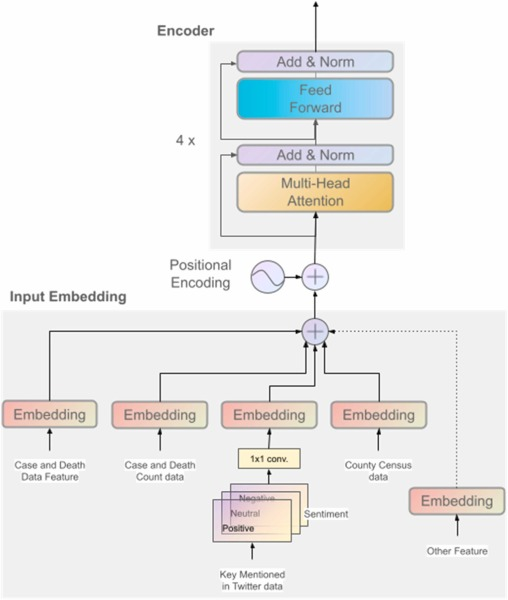


**Input Embedding**
The model first embeds the input features, case and death count data, Twitter data, county census data, and other features in the embedding step. \
They use CNN to process the sentiment analysis of Twitter before embedding it. 
They end up projecting the features into a 512-dimensional embedding space.

**Positional Encoding**
Next, they pass through the positional encoder in order to embed the order of information into the data, allowing them to understand the time flow within the input. \
The mathematical relationship that they model is $y_{(t+k)},...,y_t = f_k(x_{(t-w)},...,x_{(t-1)})$ .For our work, the k = 7. 

**Why they decide to not include the decoder?**
They decided to remove the decoder because it results in "simplifying the model, reducing training time, and improving performance by emphasizing direct representation learning over autoregressive decoding." \
The features fed to the model are also processed; the decoder is not essential and can cause potential overfitting. 

**Transformer Encoder**
In the encoder, they use four transformer encoder layers before outputting a prediction. Each trasformer and encoder has attention heads and a feedforward network, which can be largely simplified as in this diagram:

Input sequence -> Transformer Encoder #1 -> Transformer Encoder #2 -> Transformer Encoder #3 -> Transformer Encoder #4 -> Prediction

**Attention Heads** There are 8 attention heads, 64-dimensional for Q, K, and V, and a dropout rate of 0.1. 
The reason for having 8 attention heads is to focus on different aspects of the relationship between the features in the time-series dataset. 
For every time point, the Transformer creates: $Q=XW_Q$ , $K=XW_k$ , $V=XW_v$ where \(X\) is the embedded time-series representation in the last w days. Then attention is approximately: $Attention(Q,K,V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$ \
Q and K values pass through the softmax function to multiply V as a weight. 

**Feedforward network**
The purpose of the feedforward network is to transform that information into a more useful representation. The feedforward dimension is 1024 dimensions, in which the feedforward network nonlinearly transforms the vector from 512 -> expands to 1024 -> nonlinear transformation -> 512 dimensions. 

**Linear Projection**
the encoder's output is fed straight into a linear layer that projects it onto the k future values in a single forward pass. So the model doesn't "chain" predictions together — it outputs the whole forecast horizon at once.

## Training Data and Window Length

The study used a randomized window length that caps at a maximum 16-day lookback for daily prediction pr 5 weeks for weekly prediction. 
The idea was to expose the model to varying amounts of historical context so it would generalize better and not overfit to one specific window size.
Randomized in this case means that the model might use a 5-day lookback and then another time 16 day look back.
The study noted that the weekly forecast model is better than the daily forecast model. 

## Rough sketch of Our Transformer Architecture

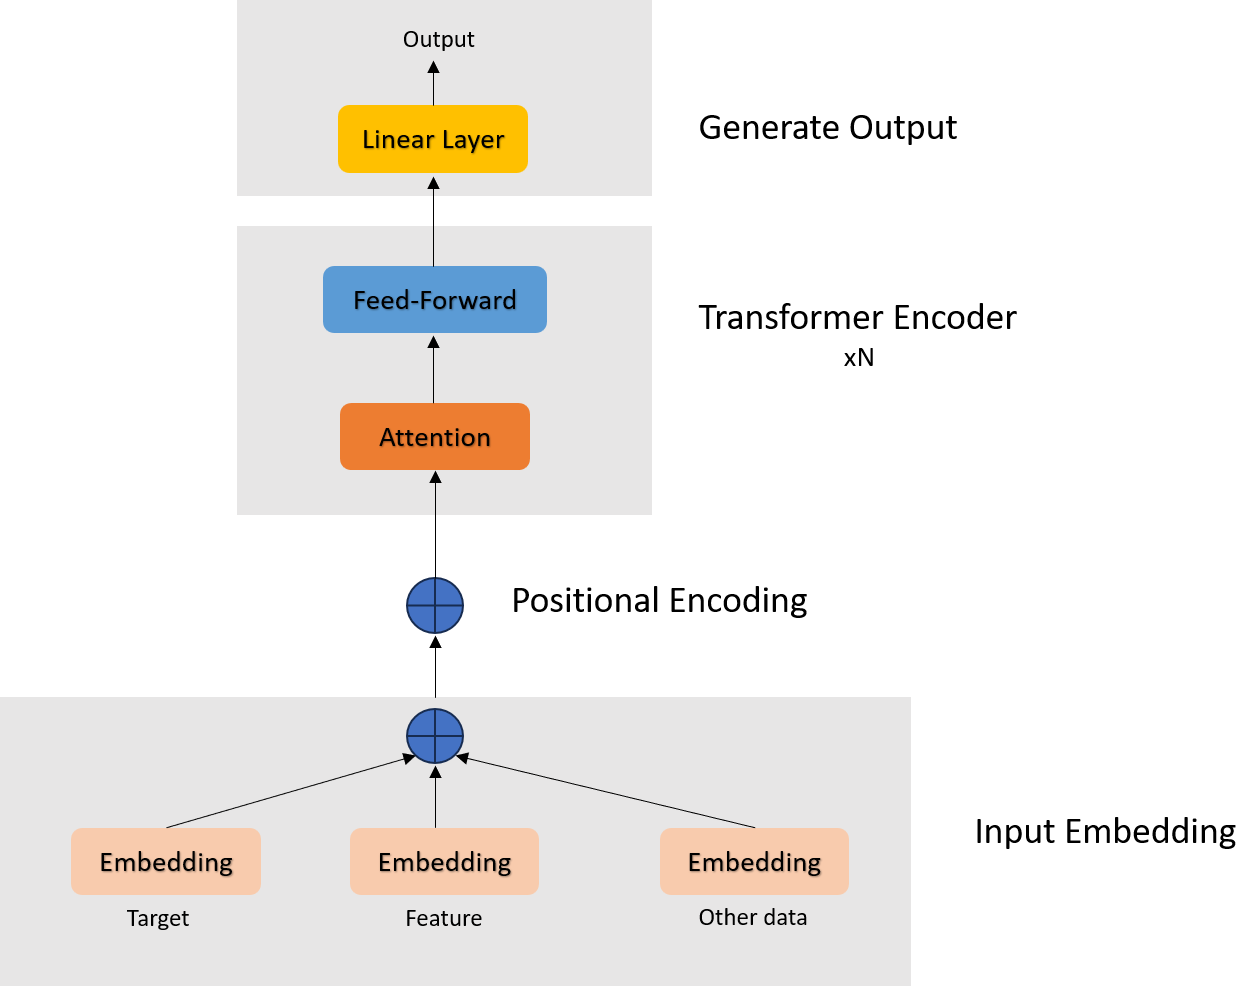

# Features used in our model

|Variable|RF Feature Importance|
|--------|---------------------|
|days_since_outbreak_county|0.110044|
|log_own_outbreaks_7d|0.090045|
|log_own_outbreaks_21d|0.086476|
|log_own_outbreaks_60d|0.050954|
|log_layer_inventory|0.045355|
|log_wintering_side_pressure|0.035853|
|doy_sin|0.032886|
|days_since_outbreak_neighbor|0.032494|
|log_turkey_operations|0.031496|
|log_poultry_operations|0.030688|

We will use doy_sin for a cyclical representation of day-of-year feature and convert day into number of days from the present day.max() - day to indicate for a look back window in days. \
We also have to include state and county (fips in data set) into the data too since the model needs that information.

## Instructions for importing the ML libraries

Since you're building the neural network model, sync that extra:

uv sync --extra ml

If you also need the classical-modeling stack in the same environment (e.g. comparing against the sklearn baseline in the same notebook), you can request multiple extras at once:

uv sync --extra ml --extra dev

Then launch the notebook the usual project way so it picks up the synced env:

uv run --extra dev jupyter lab

## 1. Load and Transform Data

In [1]:
# import libraries
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

from h5n1.db import get_engine

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

In [38]:
# import data from database
QUERY = f"""
SELECT fips, day, state,
       target_outbreak_next_7d,
       outbreak, own_outbreaks_7d, own_outbreaks_21d, own_outbreaks_60d,
       nbr_infected_counties_7d, nbr_infected_counties_21d, nbr_infected_counties_60d,
       nbr_infections_7d, nbr_infections_21d, nbr_infections_60d,
       nbr_wild_detections_7d, nbr_wild_detections_21d, nbr_wild_detections_60d,
       wild_detections_7d, wild_detections_21d, wild_detections_60d,
       band_count_21d, nbr_band_count_21d, has_band_coverage,
       days_since_outbreak_county, days_since_outbreak_neighbor,
       breeding_side_pressure, wintering_side_pressure,
       temp_min_7d_c, temp_max_7d_c, precip_7d_mm, precip_days_7d,
       poultry_operations, layer_operations, broiler_operations,
       turkey_operations, duck_operations, layer_inventory,
       population, pop_density_sqmi, n_neighbors, doy_sin, doy_cos
FROM feature_county_day
WHERE is_conus
  AND target_complete_7d
"""
# read sql
df = pd.read_sql(QUERY, get_engine())
# transform data, convert to proper data type
df["day"] = pd.to_datetime(df["day"])

In [39]:
# calculate days_from_present
days_from_present =  (df["day"].max() - df["day"]).dt.days
df["days_from_present"] = days_from_present

In [40]:
# handling NaN
# for days_since_outbreak_county and for days_since_outbreak_neighbor, we can fill with one thousands because 400 > max of 365 
df['days_since_outbreak_county'] = df['days_since_outbreak_county'].fillna(400.0)
df['days_since_outbreak_neighbor'] = df['days_since_outbreak_neighbor'].fillna(400.0)

# for layer_inventory, the reason it is NaN due to the  deliberate government suppression. Lines 21-38 spell it out: NASS withholds county-level inventory numbers to avoid identifying a single farm's data
# data is not missing at random here
# they suppressed small farm
# we will fill with the layer_inventory each state median 
df['layer_inventory'] = (df.groupby('state')['layer_inventory'].transform(lambda s: s.fillna(s.median())))

In [42]:
# log function
def log_transform(df, list_cols):
    new_log = []
    for col in list_cols:
        new_col = f"log_{col}"
        new_log.append(new_col)
        df[new_col] = np.log1p(df[col].clip(lower=0)) #prevent log of zero and negative
    return new_log

In [43]:
# map function
def map_category(df, list_cols, list_vocabs):
    for i in range(len(list_cols)):
        map_categories = pd.Categorical(df[list_cols[i]])
        vocabs = {cat: idx for idx, cat in enumerate(map_categories.categories)}
        list_vocabs.append(vocabs)
        df[list_cols[i]] = df[list_cols[i]].map(vocabs)

In [44]:
# transform the data: standard scaler, apply log, convert bool to float
# apply log and drop non log column
log_list = ["own_outbreaks_7d", "own_outbreaks_21d", "own_outbreaks_60d", "layer_inventory", "wintering_side_pressure", "turkey_operations", "poultry_operations"]
new_log = log_transform(df, log_list)
df = df.drop(columns = log_list)
# standard scaler
scaler = StandardScaler()
scale_list = [i for i in new_log if i not in ["fips", "state","days_from_present"]]
df.loc[:,scale_list] = scaler.fit_transform(df.loc[:,scale_list])
# convert bool to float
df["target_outbreak_next_7d"] = df["target_outbreak_next_7d"].astype(float)
# convert date to float
df["days_from_present"] = df["days_from_present"].astype(float)

# map each state and fips to a number
list_vocabs = []
map_category(df, list_cols = ["state", "fips"], list_vocabs = list_vocabs)


In [45]:
# group by days from present, counties/fips, mean
#last 2 days of records and select only the important features
# we do this so the embedded vector able to separate the data by look back window
# select the columns and aggregate them
df_filtered = df.loc[df["days_from_present"] <= 2,["target_outbreak_next_7d", "fips", "state", "days_from_present", "days_since_outbreak_county","log_own_outbreaks_7d","log_own_outbreaks_21d","log_own_outbreaks_60d","log_layer_inventory","log_wintering_side_pressure","doy_sin","days_since_outbreak_neighbor","log_turkey_operations","log_poultry_operations"]]
df_groupby = df_filtered.groupby(['days_from_present', 'state', 'fips']).mean(numeric_only=True)
# sort in the way that each county data is next to each other sequantially by days from present
df_groupby = df_groupby.sort_values(['fips', 'days_from_present']).reset_index()

## Input Embedding

In [53]:
#convert to tensor
category_col = ["state", "fips"]
exclude_cols = category_col + ["target_outbreak_next_7d"]
# tensor_target = torch.tensor(df_groupby['target_outbreak_next_7d'].values, dtype=torch.float32).unsqueeze(-1) # (9324, 1)
tensor_feature_num = torch.tensor(df_groupby.loc[:, [i for i in df_groupby.columns if i not in exclude_cols]].values, dtype=torch.float32)  # (9324, 11)
tensor_feature_state = torch.tensor(df_groupby[category_col[0]].values, dtype=torch.long)
tensor_feature_fips = torch.tensor(df_groupby[category_col[1]].values, dtype=torch.long)

In [79]:
# input embedding class
class MultiSourceEmbedding(nn.Module):
    def __init__(self, n_feature_num, n_feature_state, n_feature_fips, embed_dimension = 512):
        super().__init__()
        #torch.nn.Linear for continuous features and torch.nn.Embedding(num_categories, embedding_dim) for categorical 
        self.embedded_feature_layer = nn.Linear(n_feature_num, embed_dimension)
        self.state_embed = nn.Embedding(num_embeddings=n_feature_state, embedding_dim=embed_dimension)
        self.county_embed = nn.Embedding(num_embeddings=n_feature_fips, embedding_dim=embed_dimension)
        self.embed_dimension = embed_dimension

    def forward(self, tensor_feature_num, tensor_feature_state, tensor_feature_fips):
        # input embedding the feature numerical
        embedded_feature = self.embedded_feature_layer(tensor_feature_num)
        # input embedding the feature categorical for state
        state_vecs = self.state_embed(tensor_feature_state)
        # input embedding the feature categorical for fips
        county_vecs = self.county_embed(tensor_feature_fips)
        #fuse the input embedded together
        return  embedded_feature + state_vecs + county_vecs

    def reshape(self, df, seq_col, batch_col, fuse_embedded):
        seq_len = df[seq_col].nunique()   # 3 (days 0, 1, 2)
        batch   = df[batch_col].nunique()
        # guard: reshape only makes sense if every county has exactly seq_len rows
        counts = df.groupby(batch_col).size()
        assert (counts == seq_len).all(), f"{(counts != seq_len).sum()} counties don't have all {seq_len} days"
        # return the reshape vector
        return fuse_embedded.view(batch, seq_len, self.embed_dimension)
        

In [80]:
input_embedding = MultiSourceEmbedding(n_feature_num=11, n_feature_state=len(list_vocabs[0]), n_feature_fips=len(list_vocabs[1]), embed_dimension = 512)
fuse_embedded = input_embedding.forward(tensor_feature_num, tensor_feature_state, tensor_feature_fips)
fuse_embedded_seq = input_embedding.reshape(df_groupby, seq_col = 'days_from_present', batch_col = 'fips', fuse_embedded = fuse_embedded)

## Math behind the Positional Encoding

final[pos][dim] = fused[pos][dim] + pe[pos][dim]
* Our dimension in this case is 512
* Pos is the position in the fused embedding
* The final vector is the fused vector, adding with the Positional Encoding of that particular in position in the vector

PE(pos, 2i)   = sin(pos / 10000^(2i/d_model)) \
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

Wu et al. used and cited the positional encoding according to this paper: https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf


In [82]:
# Positional encoding class
# Standard sinusoidal positional encoding (Vaswani et al., 2017).
# Input to the class is the dimension (512) and the max_len, which is days of the look back windows
# The output of the PE vector before adding to tensor is size (batch (row numbers), seq_len (lookback window), d_model (dimension))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 20):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)
 
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, : x.size(1), :]


In [83]:
positional_encoding = PositionalEncoding(d_model=embed_dimension, max_len=3)
positional_encoded_vector = positional_encoding.forward(fuse_embedded_seq)

## Transformer Encoder